<a href="https://colab.research.google.com/github/gavrilovAlikhan/ML-Practice/blob/main/Student%20Scores/student_scores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [1]:
%pip install catboost lightgbm optuna

## Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px 

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import TargetEncoder, OneHotEncoder, StandardScaler, MinMaxScaler

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.base import clone

from sklearn.model_selection import StratifiedKFold, KFold,cross_validate, cross_val_score, cross_val_predict
from sklearn.metrics import root_mean_squared_error

from xgboost import XGBRegressor
import lightgbm as lgb
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor, Pool
from sklearn.linear_model import LinearRegression, Ridge, SGDRegressor, HuberRegressor, Lasso


import optuna

import typing

import warnings

%matplotlib inline

KeyboardInterrupt: 

In [ ]:
import plotly.io as pio
pio.renderers.default = "vscode"

In [ ]:
TARGET = "exam_score"
N_SPLITS = 5
SEED = 42
eps = 1e-5

def check_environment():
    try:
        import google.colab
        env = "colab"
    except ImportError:
        env = "local"
    return env

ENVIRONMENT = check_environment()

non_relevant_columns = ['id', 'source']

ordinal_maps = {
    "gender" : {"male":0, "female":1, "other":2},
    "internet_access" : {"no":0, "yes":1},
    "sleep_quality" : {"poor":0, "average":1, "good":2},
    "facility_rating" : {"low":0, "medium":1, "high":2},
    "exam_difficulty" : {"easy":0, "moderate":1, "hard":2},
    "course" : {"ba":0, "b.sc":1, "diploma":2, "b.tech":3, "b.com":4, "bca":5, "bba":6},
    "study_method" : {"self-study":0, "online videos":1, "group study":2, "mixed":3, "coaching":4},
}

original_categorical_cols = ['gender', 'course', 'internet_access', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']


# Data Loader

In [ ]:
def load_data(option: str="local"):
  '''
  returns train_df, test_df, df

  '''
  if option == "local":
    train_df = pd.read_csv('train.csv')
    test_df = pd.read_csv('test.csv')

  elif option == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')
    train_df = pd.read_csv('/content/drive/MyDrive/Kaggle Practice/Student Scores/train.csv')
    test_df = pd.read_csv('/content/drive/MyDrive/Kaggle Practice/Student Scores/test.csv')

  train_df['source'] = 'train'
  test_df['source'] = 'test'
  df = pd.concat([train_df, test_df], ignore_index=True)

  return train_df, test_df, df

In [ ]:
df_train, _, df = load_data(option=ENVIRONMENT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data Splitter

In [ ]:
def data_spliter(df: pd.DataFrame, additional_drop_columns: list = []) -> tuple[pd.DataFrame, pd.Series, pd.DataFrame]:
    '''
    return: X_train, y_train, submission_df

    '''
    train_dataset = df[df['source'] == 'train'].drop(columns=non_relevant_columns + additional_drop_columns)
    submission_dataset = df[df['source'] == 'test'].drop(columns=['source', TARGET] + additional_drop_columns)

    X_train = train_dataset.drop(columns=[TARGET])
    y_train = train_dataset[TARGET]

    return X_train, y_train, submission_dataset

# EDA

In [ ]:
df.isna().sum()

,0
id,0
age,0
gender,0
course,0
study_hours,0
class_attendance,0
internet_access,0
sleep_hours,0
sleep_quality,0
study_method,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900000 entries, 0 to 899999
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                900000 non-null  int64  
 1   age               900000 non-null  int64  
 2   gender            900000 non-null  object 
 3   course            900000 non-null  object 
 4   study_hours       900000 non-null  float64
 5   class_attendance  900000 non-null  float64
 6   internet_access   900000 non-null  object 
 7   sleep_hours       900000 non-null  float64
 8   sleep_quality     900000 non-null  object 
 9   study_method      900000 non-null  object 
 10  facility_rating   900000 non-null  object 
 11  exam_difficulty   900000 non-null  object 
 12  exam_score        630000 non-null  float64
 13  source            900000 non-null  object 
dtypes: float64(4), int64(2), object(8)
memory usage: 96.1+ MB


In [ ]:
df.drop(columns=non_relevant_columns).describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,900000.0,NaN,NaN,NaN,20.545316,2.260301,17.0,19.0,21.0,23.0,24.0
gender,900000,3,male,301275,NaN,NaN,NaN,NaN,NaN,NaN,NaN
course,900000,7,b.tech,187697,NaN,NaN,NaN,NaN,NaN,NaN,NaN
study_hours,900000.0,NaN,NaN,NaN,4.0028,2.359238,0.08,1.98,4.0,6.05,7.91
class_attendance,900000.0,NaN,NaN,NaN,71.985836,17.425469,40.6,57.0,72.6,87.2,99.4
internet_access,900000,2,yes,828094,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sleep_hours,900000.0,NaN,NaN,NaN,7.072552,1.745021,4.1,5.6,7.1,8.6,9.9
sleep_quality,900000,3,poor,305355,NaN,NaN,NaN,NaN,NaN,NaN,NaN
study_method,900000,5,coaching,188395,NaN,NaN,NaN,NaN,NaN,NaN,NaN
facility_rating,900000,3,medium,305898,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Correlations

In [ ]:
z = df.drop(columns=non_relevant_columns).copy()
z['internet_access'] = z['internet_access'].map({'no':0, 'yes':1})
z['sleep_quality'] = z['sleep_quality'].map({'average':1, 'poor':0, 'good':2})
z['facility_rating'] = z['facility_rating'].map({'medium':1, 'low':0, 'high':2})
z['exam_difficulty'] = z['exam_difficulty'].map({'moderate':1, 'easy':0, 'hard':2})
z = pd.get_dummies(z, columns=['study_method', 'course', 'gender'], dtype=int)

In [ ]:
z_corr = z.corr()
z_sorted_cols = z_corr['exam_score'].abs().sort_values(ascending=False).index.to_list()

z_corr_sorted = z_corr.loc[z_sorted_cols, z_sorted_cols]
mask = np.triu(np.ones_like(z_corr_sorted, dtype=bool), k=1)
z_corr_sorted[mask] = np.nan

### Correlation Plot

In [ ]:
corr_fig = px.imshow(
    z_corr_sorted,
    text_auto = ".2f",
    aspect=True,
    color_continuous_scale="RdBu_r",
    width=1200,
    height=800
)

corr_fig.show()

## Distribution of categorical columns by exam score

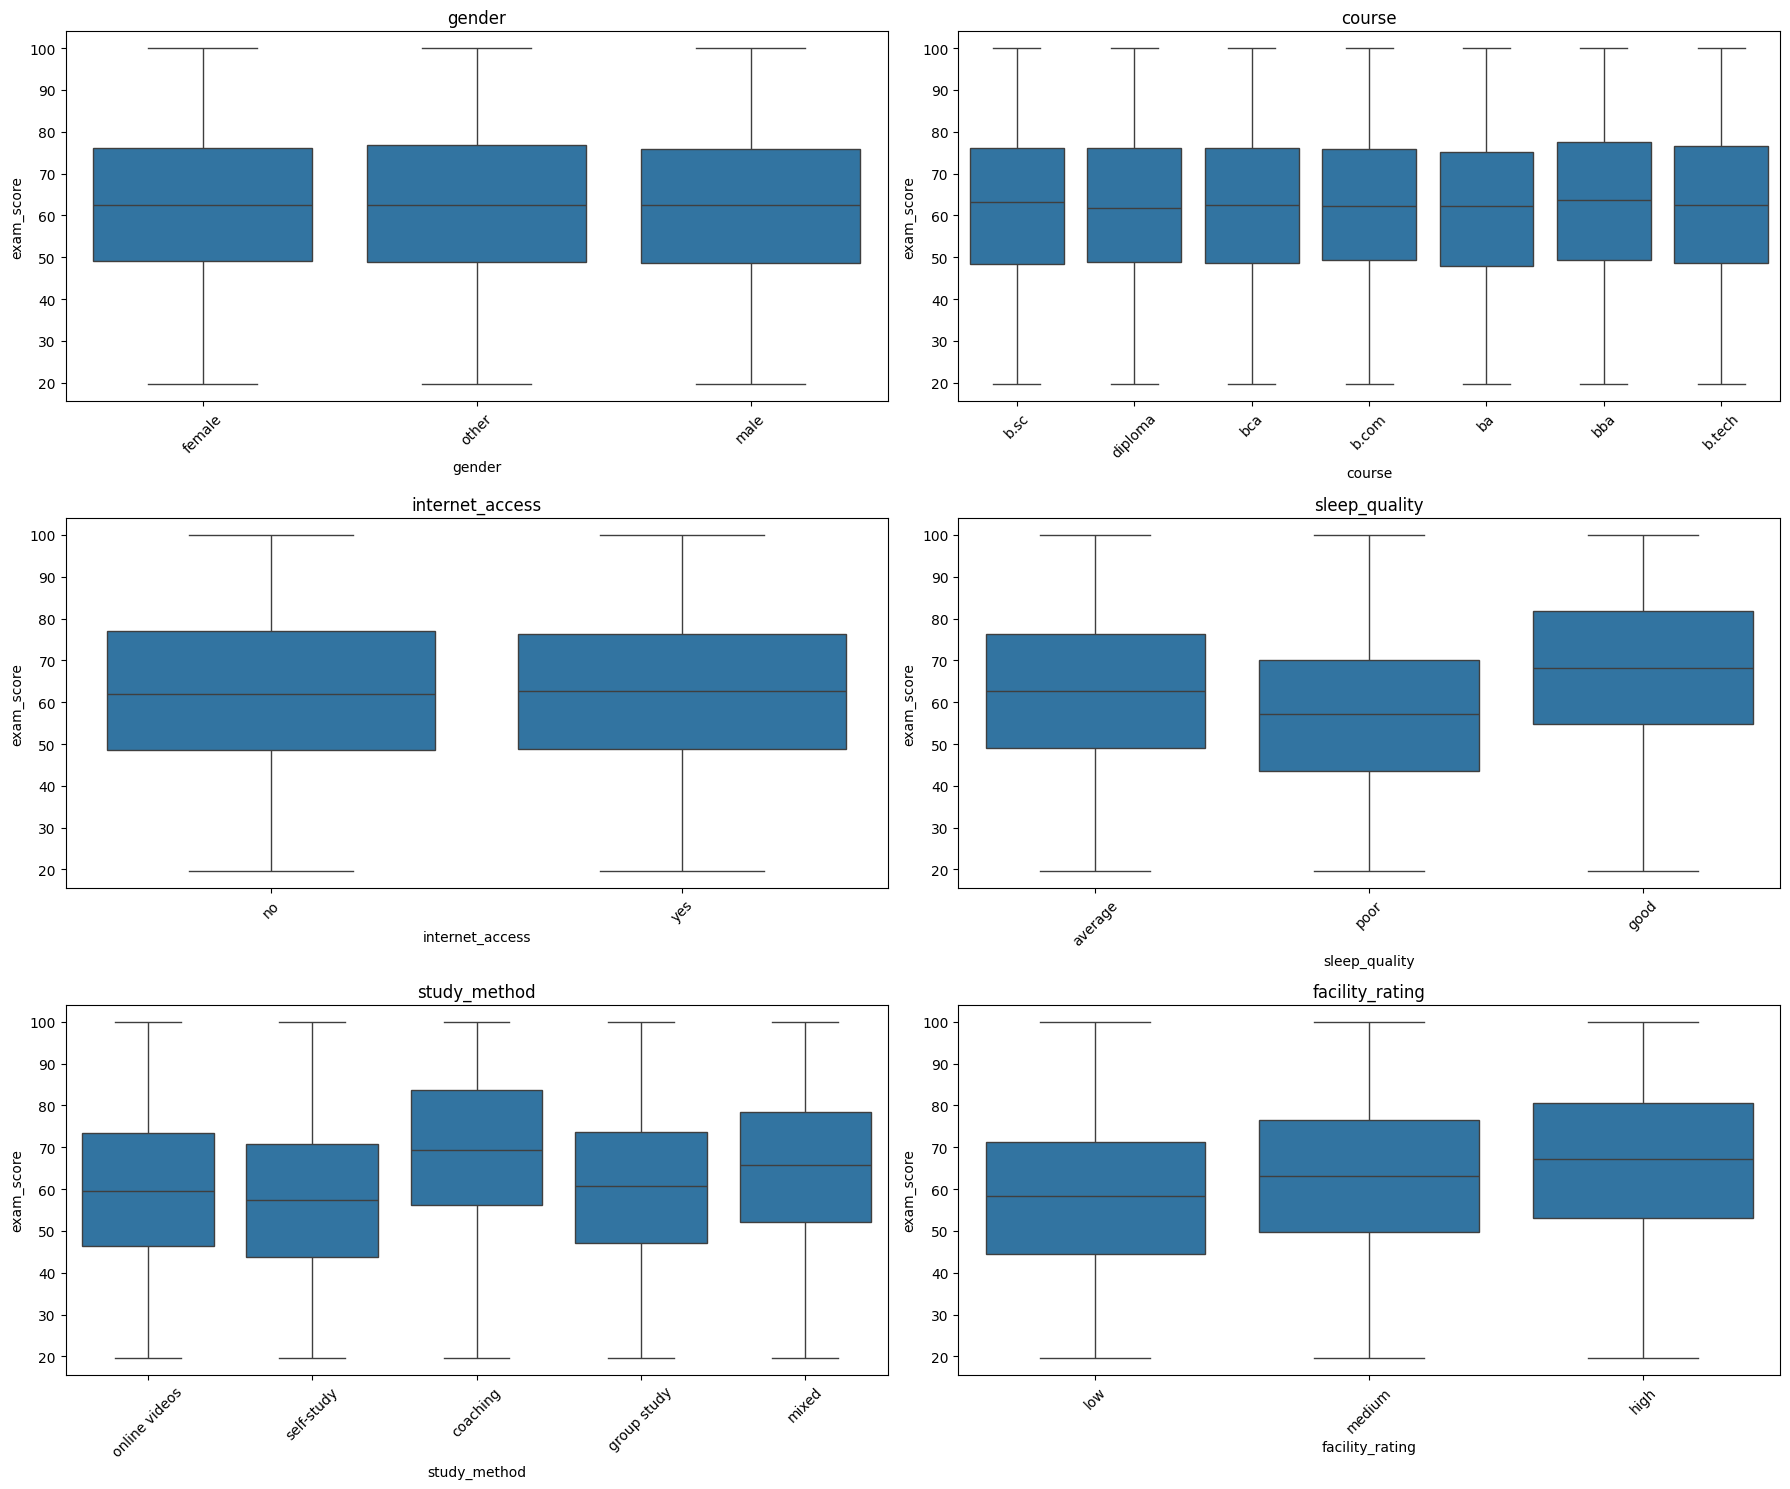

In [ ]:
rows = len(original_categorical_cols) // 3 + len(original_categorical_cols) % 3
fig, axes = plt.subplots(rows, 2, figsize=(18, 15))

for ax, c in zip(axes.flat, original_categorical_cols):
    sns.boxplot(data=df, x=c, y="exam_score", ax=ax)
    ax.set_title(c)
    ax.tick_params(axis="x", rotation=45)

# hide any leftover empty panels if you have fewer than 8 columns
for ax in axes.flat[len(original_categorical_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## Age

<Axes: xlabel='age', ylabel='exam_score'>

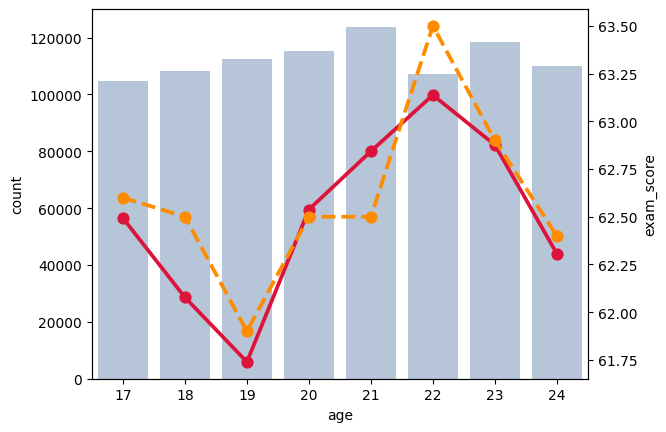

In [ ]:
ax = sns.countplot(data=df, x='age', color='lightsteelblue')
ax2 = ax.twinx()
sns.pointplot(data=df, x='age', y=TARGET, ax=ax2, color='crimson', errorbar=None)
sns.pointplot(data=df, x='age', y=TARGET, ax=ax2, color='darkorange', errorbar=None, estimator='median', linestyle='--')

## Attendance

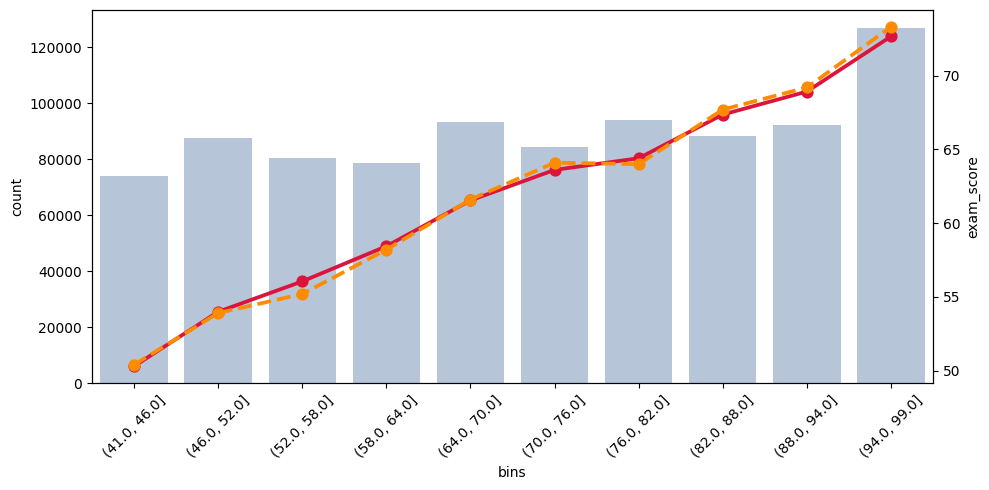

In [ ]:
plt.figure(figsize=(10,5))
plot_df = df.copy()
plot_df['bins'] = pd.cut(plot_df['class_attendance'], 10, precision=0)
order = plot_df['bins'].unique().sort_values(ascending=True)

ax = sns.countplot(data=plot_df, x='bins', color='lightsteelblue', order=order)
ax2 = ax.twinx()
sns.pointplot(data=plot_df, x='bins', y=TARGET, ax=ax2, color='crimson', errorbar=None)
sns.pointplot(data=plot_df, x='bins', y=TARGET, ax=ax2, color='darkorange', errorbar=None, estimator='median', linestyle='--')

ax.tick_params(axis='x', rotation=45)
plt.tight_layout()

## Course

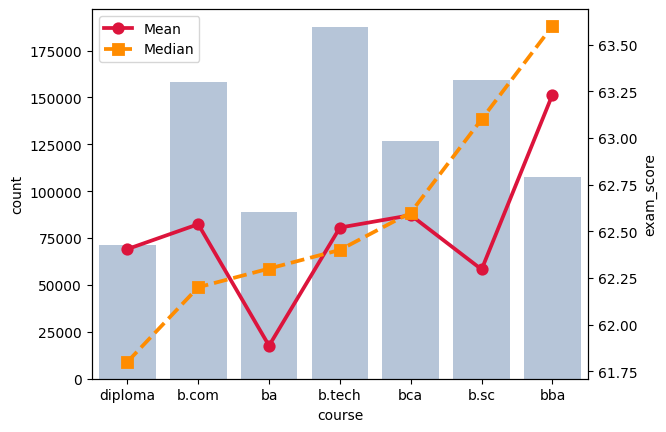

In [ ]:
col = 'course'
order = df.groupby(col)[TARGET].median().sort_values().index
ax = sns.countplot(data=df, x=col, color='lightsteelblue', order=order)
ax2 = ax.twinx()
sns.pointplot(data=df, x=col, y=TARGET, ax=ax2, color='crimson', errorbar=None, label='Mean')
sns.pointplot(data=df, x=col, y=TARGET, ax=ax2, color='darkorange', errorbar=None,
              estimator='median', linestyles='--', markers='s', label='Median')
ax2.legend()

## Sleep Quality

/tmp/ipykernel_5102/1322458394.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



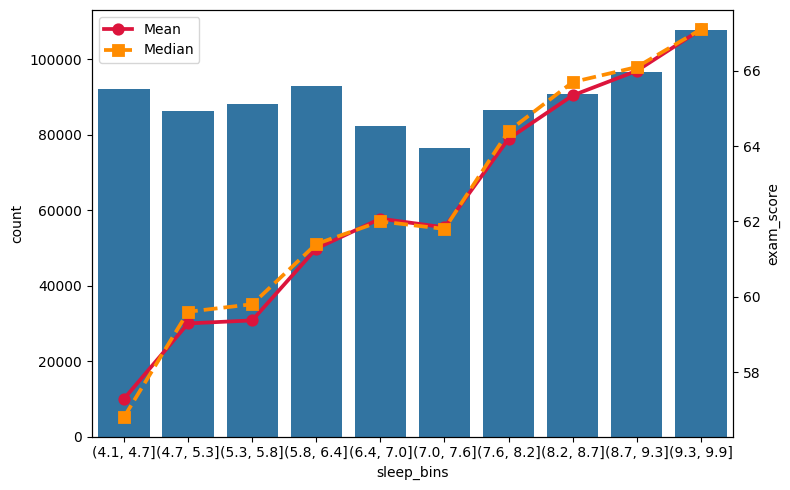

In [ ]:
plt.figure(figsize=(8,5))
plot_df = df.copy()
plot_df['sleep_bins'] = pd.cut(df.sleep_hours, 10, precision=0)
stats = plot_df.groupby('sleep_bins')['exam_score'].agg(['mean', 'median'])

order = sorted(plot_df.sleep_bins.unique().tolist())

ax = sns.countplot(plot_df, x='sleep_bins', order=order)
ax2 = ax.twinx()

sns.pointplot(data=plot_df, x='sleep_bins', y=TARGET, ax=ax2, color='crimson', errorbar=None, label='Mean')
sns.pointplot(data=plot_df, x='sleep_bins', y=TARGET, ax=ax2, color='darkorange', errorbar=None,
              estimator='median', linestyles='--', markers='s', label='Median')

plt.tight_layout()

## Study Hours

/tmp/ipykernel_5102/1885288824.py:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



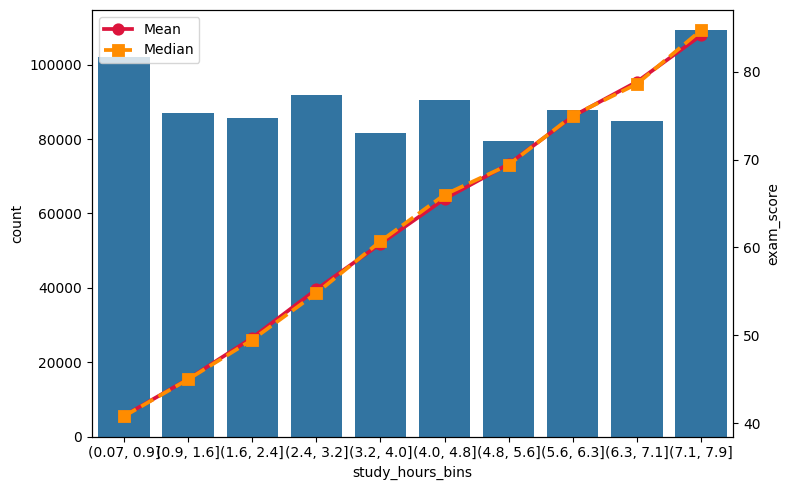

In [ ]:
col = 'study_hours'
bin_col = f'{col}_bins'

plt.figure(figsize=(8,5))
plot_df = df.copy()
plot_df[bin_col] = pd.cut(df[col], 10, precision=0)
stats = plot_df.groupby(bin_col)[TARGET].agg(['mean', 'median'])

order = sorted(plot_df[bin_col].unique().tolist())

ax = sns.countplot(plot_df, x=bin_col, order=order)
ax2 = ax.twinx()

sns.pointplot(data=plot_df, x=bin_col, y=TARGET, ax=ax2,color='crimson', errorbar=None, label='Mean')
sns.pointplot(data=plot_df, x=bin_col, y=TARGET, ax=ax2, color='darkorange',
              estimator='median', linestyles='--', markers='s', label='Median')

plt.tight_layout()

## Study Method

In [0]:
col = 'study_method'
bin_col = col

plt.figure(figsize=(8,5))
plot_df = df.copy()
stats = plot_df.groupby(bin_col)[TARGET].agg(['mean', 'median'])

order = stats.sort_values(by='median').index.tolist()

ax = sns.countplot(plot_df, x=bin_col, order=order)
ax2 = ax.twinx()

sns.pointplot(data=plot_df, x=bin_col, y=TARGET, ax=ax2,color='crimson', errorbar=None, label='Mean')
sns.pointplot(data=plot_df, x=bin_col, y=TARGET, ax=ax2, color='darkorange', errorbar=None,
              estimator='median', linestyles='--', markers='s', label='Median')

plt.tight_layout()

## Internet Acces

In [0]:
col = 'internet_access'
bin_col = col

plt.figure(figsize=(8,5))
plot_df = df.copy()
stats = plot_df.groupby(bin_col)[TARGET].agg(['mean', 'median'])

order = stats.sort_values(by='median').index.tolist()

ax = sns.countplot(plot_df, x=bin_col, order=order)
ax2 = ax.twinx()

sns.pointplot(data=plot_df, x=bin_col, y=TARGET, ax=ax2,color='crimson', label='Mean')
sns.pointplot(data=plot_df, x=bin_col, y=TARGET, ax=ax2, color='darkorange',estimator='median', linestyles='--', markers='s', label='Median')

plt.tight_layout()

# Feature Engineering

In [ ]:
def feature_engineering(fdf: pd.DataFrame, include_polynomial: bool = True, include_relationship: bool = True) -> pd.DataFrame:
    print("FEATURE ENGINEERING...")

    df: pd.DataFrame = fdf.copy()
    
    # Ranking of categories based on liner relationship with target
    for k, i in ordinal_maps.items():
        df[k] = df[k].map(i)
        
    # Relationship columns
    if include_relationship:
        for col in df.drop(columns=[TARGET] + non_relevant_columns).select_dtypes(
            include="number"
        ):
            relationship_columns: list[str] = ["study_hours", "class_attendance"]
            for r in relationship_columns:
                if col != r:
                    df[f"{r}_x_{col}"] = df[r] * df[col]
                    
    # Polynomial features
    if include_polynomial:
        for pol in df.drop(columns=[TARGET] + non_relevant_columns).select_dtypes(include="number"):
            df[f"{pol}_squared"] = df[pol] ** 2
            

    df['feature_formula'] = (
            5.9051154511950499 * df['study_hours'] +
            0.34540967058057986 * df['class_attendance'] +
            1.423461171860262 * df['sleep_hours'] + 4.7819
    )
        # Key interactions
    df['study_hours_times_attendance'] = df['study_hours'] * df['class_attendance']
    df['study_hours_times_sleep'] = df['study_hours'] * df['sleep_hours']
    df['attendance_times_sleep'] = df['class_attendance'] * df['sleep_hours']
    df['age_times_study_hours'] = df['age'] * df['study_hours']

    # Important ratios
    df['study_hours_over_sleep'] = df['study_hours'] / (df['sleep_hours'] + eps)
    df['attendance_over_sleep'] = df['class_attendance'] / (df['sleep_hours'] + eps)
    df['attendance_over_study'] = df['class_attendance'] / (df['study_hours'] + eps)

    df["study_bin_num"] = pd.cut(df["study_hours"], bins=[-1,2,4,6,8,100], labels=[0,1,2,3,4]).astype(float)
    # Print which columns were added
    new_columns: list[str] = [
        col
        for col in df.drop(columns=[TARGET] + non_relevant_columns).columns
        if col not in fdf.drop(columns=[TARGET] + non_relevant_columns)
    ]

    print(f"\nFeature Engineering Ended, added {len(new_columns)} columns:")
    for i, c in enumerate(sorted(new_columns)):
        print(f"{i}: {c}")
    return df

In [ ]:
_, _, df = load_data(option=ENVIRONMENT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = feature_engineering(df)

FEATURE ENGINEERING...

Feature Engineering Ended, added 53 columns:
0: age_squared
1: class_attendance_squared
2: class_attendance_x_age
3: class_attendance_x_age_squared
4: class_attendance_x_class_attendance_squared
5: class_attendance_x_course
6: class_attendance_x_course_squared
7: class_attendance_x_exam_difficulty
8: class_attendance_x_exam_difficulty_squared
9: class_attendance_x_facility_rating
10: class_attendance_x_facility_rating_squared
11: class_attendance_x_gender
12: class_attendance_x_gender_squared
13: class_attendance_x_internet_access
14: class_attendance_x_internet_access_squared
15: class_attendance_x_sleep_hours
16: class_attendance_x_sleep_hours_squared
17: class_attendance_x_sleep_quality
18: class_attendance_x_sleep_quality_squared
19: class_attendance_x_study_hours
20: class_attendance_x_study_hours_squared
21: class_attendance_x_study_method
22: class_attendance_x_study_method_squared
23: course_squared
24: exam_difficulty_squared
25: facility_rating_squared

In [0]:
cv = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED
)

# Ridge Regression

In [ ]:
_, _, df = load_data(option=ENVIRONMENT)
df = feature_engineering(df, include_polynomial=True, include_relationship=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
FEATURE ENGINEERING...

Feature Engineering Ended, added 60 columns:
0: age_squared
1: age_times_study_hours
2: attendance_over_sleep
3: attendance_over_study
4: attendance_times_sleep
5: class_attendance_squared
6: class_attendance_x_age
7: class_attendance_x_age_squared
8: class_attendance_x_course
9: class_attendance_x_course_squared
10: class_attendance_x_exam_difficulty
11: class_attendance_x_exam_difficulty_squared
12: class_attendance_x_facility_rating
13: class_attendance_x_facility_rating_squared
14: class_attendance_x_gender
15: class_attendance_x_gender_squared
16: class_attendance_x_internet_access
17: class_attendance_x_internet_access_squared
18: class_attendance_x_sleep_hours
19: class_attendance_x_sleep_hours_squared
20: class_attendance_x_sleep_quality
21: class_attendance_x_sleep_quality_squared
22: class_attendance_x_study_hours
23: class_a

In [ ]:
X, y, submission_df = data_spliter(df)
y_bins = pd.cut(y, 10, precision=0, labels=False)

In [ ]:
model = make_pipeline(StandardScaler(), Ridge(alpha=10))

oof_ridge = cross_val_predict(model, X, y, cv=5)
print(f"OOF RMSE: {root_mean_squared_error(y, oof_ridge):.4f}")

OOF RMSE: 8.8839


In [0]:
model = make_pipeline(StandardScaler(), HuberRegressor(epsilon=10))

oof = cross_val_predict(model, X, y, cv=cv)
print(f"OOF RMSE: {root_mean_squared_error(y, oof):.4f}")

In [0]:
model = make_pipeline(StandardScaler(), Lasso(alpha=10))

oof = cross_val_predict(model, X, y, cv=cv)
print(f"OOF RMSE: {root_mean_squared_error(y, oof):.4f}")

In [0]:
print(root_mean_squared_error(y, oof))

# LightGBM

In [ ]:
_, _, df = load_data(option=ENVIRONMENT)
df = feature_engineering(df, include_polynomial=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
FEATURE ENGINEERING...

Feature Engineering Ended, added 9 columns:
0: age_times_study_hours
1: attendance_over_sleep
2: attendance_over_study
3: attendance_times_sleep
4: feature_formula
5: study_bin_num
6: study_hours_over_sleep
7: study_hours_times_attendance
8: study_hours_times_sleep


In [ ]:
X, y, submission_df = data_spliter(df)

# model.fit(X, y)
# submission_df['ridge_pred'] = model.predict(submission_df.drop(columns='id'))
# X['ridge_pred'] = oof_ridge
y_bins = pd.cut(y, 10, precision=0, labels=False)

In [ ]:
oof_lgb = np.zeros(len(X))
results_lgb = np.zeros(len(submission_df))

X_sub_raw = submission_df.drop(columns='id')

train_rmse_scores, valid_rmse_scores = [], []

best_iterations = []

In [ ]:
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_bins)):

    print(f"\n ======= TRAINING FOLD: {fold + 1} =======")
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = LGBMRegressor(
        objective='regression',
        metric='rmse',
        n_estimators=5000,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.7,
        subsample_freq=1,
        colsample_bytree=0.6,
        random_state=SEED,
        verbose=-1,
        device="gpu"
    )
    model.fit(
        X_train,
        y_train,
        eval_metric="rmse",
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=200),
                   lgb.log_evaluation(period=500)]
    )

    train_prediction = model.predict(X_train)
    validation_prediction = model.predict(X_val)
    oof[val_idx] = validation_prediction
    best_iterations.append(model.best_iteration_)

    train_rmse = root_mean_squared_error(y_train, train_prediction)
    validation_rmse = root_mean_squared_error(y_val, validation_prediction)

    train_rmse_scores.append(train_rmse)
    valid_rmse_scores.append(validation_rmse)

    results_lgb += model.predict(X_sub_raw) / N_SPLITS

    print(f"======= FOLD: {fold + 1} =======")
    print(f"TRAIN RMSE: {train_rmse} | VALID RMSE: {validation_rmse}\n | DELTA: {validation_rmse - train_rmse} | BEST ITER: {model.best_iteration_}")

tr, va = np.array(train_rmse_scores), np.array(valid_rmse_scores)
print("\n====== CROSS VALIDATION ENDED ======")
print(f"TRAIN AVG RMSE: {tr.mean():.5f} +/- {tr.std():.5f} | "
      f"VAL AVG RMSE: {va.mean():.5f} +/- {va.std():.5f}")
print(f"MEAN BEST ITER: {np.mean(best_iterations):.0f}")
print(f"\nOOF RMSE: {root_mean_squared_error(y, oof_lgb):.5f}")



 ======= TRAINING FOLD: 1 =======
Training until validation scores don't improve for 200 rounds
[500]	valid_0's rmse: 8.79695
[1000]	valid_0's rmse: 8.78248
[1500]	valid_0's rmse: 8.77853
Early stopping, best iteration is:
[1471]	valid_0's rmse: 8.77834


NameError: name 'oof' is not defined

In [0]:
submission_df_lgb = submission_df.copy()
submission_df_lgb[TARGET] = results_lgb
submission_df_lgb[['id', TARGET]].to_csv('lgb_submission_v2.csv', index=False)

# XGBoost

In [ ]:
_, _, df = load_data(option=ENVIRONMENT)
df = feature_engineering(df, include_polynomial=True, include_relationship=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
FEATURE ENGINEERING...

Feature Engineering Ended, added 60 columns:
0: age_squared
1: age_times_study_hours
2: attendance_over_sleep
3: attendance_over_study
4: attendance_times_sleep
5: class_attendance_squared
6: class_attendance_x_age
7: class_attendance_x_age_squared
8: class_attendance_x_course
9: class_attendance_x_course_squared
10: class_attendance_x_exam_difficulty
11: class_attendance_x_exam_difficulty_squared
12: class_attendance_x_facility_rating
13: class_attendance_x_facility_rating_squared
14: class_attendance_x_gender
15: class_attendance_x_gender_squared
16: class_attendance_x_internet_access
17: class_attendance_x_internet_access_squared
18: class_attendance_x_sleep_hours
19: class_attendance_x_sleep_hours_squared
20: class_attendance_x_sleep_quality
21: class_attendance_x_sleep_quality_squared
22: class_attendance_x_study_hours
23: class_a

In [ ]:
X, y, submission_df = data_spliter(df)

model.fit(X, y)
submission_df['ridge_pred'] = model.predict(submission_df.drop(columns='id'))
X['ridge_pred'] = oof_ridge

y_bins = pd.cut(y, 10, precision=0, labels=False)

In [ ]:
oof_xgb = np.zeros(len(X))
results_xgb = np.zeros(len(submission_df))

X_sub_raw = submission_df.drop(columns="id")

train_rmse_scores, valid_rmse_scores = [], []

best_iterations_xgb = []

In [ ]:
skf = StratifiedKFold(n_splits=N_SPLITS, random_state=SEED, shuffle=True)

In [ ]:
def objective_xgb(trial: optuna.Trial) -> float:
    param = {
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "n_estimators": 5000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 40),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 10),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 10),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "random_state": SEED,
        "device": "cuda",
        "tree_method": "hist",
        "early_stopping_rounds": 200
    }

    oof_xgb = np.zeros(len(X))
    iters = []
    skf = StratifiedKFold(n_splits=N_SPLITS, random_state=SEED, shuffle=True)

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_bins)):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

        model = XGBRegressor(**param)
        model.fit(
            X_train,
            y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        validation_prediction = model.predict(X_val)
        oof_xgb[val_idx] = validation_prediction
        iters.append(model.best_iteration)

        trial.report(root_mean_squared_error(y_val, oof_xgb[val_idx]), fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    trial.set_user_attr("best_iters", iters)

    return root_mean_squared_error(y, oof_xgb)


xgb_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10 ,n_warmup_steps=2),
)
optuna.logging.set_verbosity(optuna.logging.WARNING)
xgb_study.optimize(objective_xgb, n_trials=50, show_progress_bar=True)

print(xgb_study.best_value)
print(xgb_study.best_params)

  0%|          | 0/50 [00:00<?, ?it/s]

: 

: 

In [3]:
print(xgb_study.best_value)
print(xgb_study.best_params)

NameError: name 'xgb_study' is not defined

In [99]:
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_bins)):

    print(f"\n ======= TRAINING FOLD: {fold + 1} =======")
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

    model = XGBRegressor(
        objective="reg:squarederror",
        eval_metric="rmse",
        n_estimators=5000,
        learning_rate=0.05,
        min_child_weight=20,
        max_depth=6,
        reg_alpha=3,
        reg_lambda=6,
        colsample_bytree=0.6,
        subsample=0.85,
        early_stopping_rounds=200,
        random_state=SEED,
        device="cuda",
        tree_method="hist"
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=500
    )

    train_prediction = model.predict(X_train)
    validation_prediction = model.predict(X_val)
    oof_xgb[val_idx] = validation_prediction
    best_iterations_xgb.append(model.best_iteration)

    train_rmse = root_mean_squared_error(y_train, train_prediction)
    validation_rmse = root_mean_squared_error(y_val, validation_prediction)

    train_rmse_scores.append(train_rmse)
    valid_rmse_scores.append(validation_rmse)

    results_xgb += model.predict(X_sub_raw) / N_SPLITS

    print(f"======= FOLD: {fold + 1} =======")
    print(f"TRAIN RMSE: {train_rmse} | VALID RMSE: {validation_rmse}\n | DELTA: {validation_rmse - train_rmse} | BEST ITER: {model.best_iteration}")

tr, va = np.array(train_rmse_scores), np.array(valid_rmse_scores)
print("\n====== CROSS VALIDATION ENDED ======")
print(f"TRAIN AVG RMSE: {tr.mean():.5f} +/- {tr.std():.5f} | "
      f"VAL AVG RMSE: {va.mean():.5f} +/- {va.std():.5f}")
print(f"MEAN BEST ITER: {np.mean(best_iterations_xgb):.0f}")
print(f"\nOOF RMSE: {root_mean_squared_error(y, oof_xgb):.5f}")



 ======= TRAINING FOLD: 1 =======
[0]	validation_0-rmse:18.17611
[500]	validation_0-rmse:8.77107
[1000]	validation_0-rmse:8.75343
[1500]	validation_0-rmse:8.74816
[1774]	validation_0-rmse:8.74865
======= FOLD: 1 =======
TRAIN RMSE: 8.337216911637327 | VALID RMSE: 8.74786698979039
 | DELTA: 0.4106500781530631 | BEST ITER: 1574

 ======= TRAINING FOLD: 2 =======
[0]	validation_0-rmse:18.18272
[500]	validation_0-rmse:8.73470
[1000]	validation_0-rmse:8.71724
[1500]	validation_0-rmse:8.71238
[1723]	validation_0-rmse:8.71217
======= FOLD: 2 =======
TRAIN RMSE: 8.3584499854113 | VALID RMSE: 8.711810998966111
 | DELTA: 0.353361013554812 | BEST ITER: 1523

 ======= TRAINING FOLD: 3 =======
[0]	validation_0-rmse:18.17656
[500]	validation_0-rmse:8.76364
[1000]	validation_0-rmse:8.74344
[1500]	validation_0-rmse:8.73764
[2000]	validation_0-rmse:8.73633
[2091]	validation_0-rmse:8.73639
======= FOLD: 3 =======
TRAIN RMSE: 8.275319140017679 | VALID RMSE: 8.736031332654912
 | DELTA: 0.4607121926372333

In [100]:
submission_df_xgb = submission_df.copy()
submission_df_xgb[TARGET] = results_xgb
if ENVIRONMENT == "colab":
    submission_df_xgb[['id', TARGET]].to_csv('/content/drive/MyDrive/Kaggle Practice/Student Scores/xgb_submission_ridge_v1.csv', index=False)
else:
    submission_df_xgb[['id', TARGET]].to_csv('xgb_submission_ridge_v1.csv', index=False)

# Catboost

In [ ]:
_, _, df = load_data(option=ENVIRONMENT)
df = feature_engineering(df, include_polynomial=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
FEATURE ENGINEERING...

Feature Engineering Ended, added 9 columns:
0: age_times_study_hours
1: attendance_over_sleep
2: attendance_over_study
3: attendance_times_sleep
4: feature_formula
5: study_bin_num
6: study_hours_over_sleep
7: study_hours_times_attendance
8: study_hours_times_sleep


In [ ]:
for cat_col in original_categorical_cols:
    df[cat_col] = df[cat_col].astype("str")

In [ ]:
X, y, submission_df = data_spliter(df)
y_bins = pd.cut(y, 10, precision=0, labels=False)

oof_cb = np.zeros(len(X))
results_cb = np.zeros(len(submission_df))

X_sub_raw = submission_df.drop(columns='id')
sub_pool = Pool(X_sub_raw[X.columns], cat_features=original_categorical_cols)
train_rmse_scores, valid_rmse_scores = [], []
best_iterations_cb = []

In [ ]:
skf = StratifiedKFold(
    n_splits=N_SPLITS,
    random_state=SEED,
    shuffle=True
)

In [ ]:
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_bins)):

    print(f"\n ======= TRAINING FOLD: {fold + 1} =======")
    y_train = y.iloc[train_idx]
    y_val =  y.iloc[val_idx]
    
    train_pool = Pool(X.iloc[train_idx], y.iloc[train_idx], cat_features=original_categorical_cols)
    val_pool = Pool(X.iloc[val_idx], y.iloc[val_idx], cat_features=original_categorical_cols)

    model =CatBoostRegressor(
        iterations=5000,
        learning_rate=0.07,
        depth=6,
        l2_leaf_reg=3,
        random_seed=SEED,
        random_strength=3.4165471601740314,
        eval_metric='RMSE',
        bootstrap_type='Bernoulli',
        one_hot_max_size=2,
        # rsm=0.6, # only works on cpu 
        subsample=0.85,
        early_stopping_rounds=200,
        verbose=500,
        task_type="GPU",
        devices="0"
    )

    model.fit(
        train_pool,
        eval_set=val_pool,
        use_best_model=True
    )

    train_prediction = model.predict(train_pool)
    validation_prediction = model.predict(val_pool)
    oof_cb[val_idx] = validation_prediction
    best_iterations_cb.append(model.best_iteration_)

    train_rmse = root_mean_squared_error(y_train, train_prediction)
    validation_rmse = root_mean_squared_error(y_val, validation_prediction)

    train_rmse_scores.append(train_rmse)
    valid_rmse_scores.append(validation_rmse)

    results_cb += model.predict(sub_pool) / N_SPLITS

    print(f"======= FOLD RESULTS: {fold + 1} =======")
    print(f"TRAIN RMSE: {train_rmse} | VALID RMSE: {validation_rmse}\n | DELTA: {validation_rmse - train_rmse} | BEST ITER: {model.best_iteration_}")

tr, va = np.array(train_rmse_scores), np.array(valid_rmse_scores)
print("\n====== CROSS VALIDATION ENDED ======")
print(f"TRAIN AVG RMSE: {tr.mean():.5f} +/- {tr.std():.5f} | "
      f"VAL AVG RMSE: {va.mean():.5f} +/- {va.std():.5f}")
print(f"MEAN BEST ITER: {np.mean(best_iterations_cb):.0f}")
print(f"\nOOF RMSE: {root_mean_squared_error(y, oof_cb):.5f}")



 ======= TRAINING FOLD: 1 =======
0:	learn: 18.0363003	test: 18.0253710	best: 18.0253710 (0)	total: 51ms	remaining: 4m 14s
500:	learn: 8.7824062	test: 8.8238498	best: 8.8238498 (500)	total: 22.3s	remaining: 3m 20s
1000:	learn: 8.7348844	test: 8.8069809	best: 8.8069809 (1000)	total: 43s	remaining: 2m 51s
1500:	learn: 8.6969024	test: 8.7992027	best: 8.7991585 (1495)	total: 1m 4s	remaining: 2m 31s
2000:	learn: 8.6644713	test: 8.7949255	best: 8.7949255 (2000)	total: 1m 25s	remaining: 2m 7s
2500:	learn: 8.6346455	test: 8.7926931	best: 8.7925826 (2495)	total: 1m 47s	remaining: 1m 47s
3000:	learn: 8.6061278	test: 8.7914939	best: 8.7913576 (2970)	total: 2m 8s	remaining: 1m 25s
3500:	learn: 8.5791802	test: 8.7908908	best: 8.7907180 (3387)	total: 2m 30s	remaining: 1m 4s
bestTest = 8.790717958
bestIteration = 3387
Shrink model to first 3388 iterations.
======= FOLD RESULTS: 1 =======
TRAIN RMSE: 8.5944100405033 | VALID RMSE: 8.790716829300587
 | DELTA: 0.1963067887972869 | BEST ITER: 3387

 ====

In [63]:
submission_df_cb = submission_df.copy()
submission_df_cb[TARGET] = results_cb
if ENVIRONMENT == "colab":
    submission_df_cb[['id', TARGET]].to_csv('/content/drive/MyDrive/Kaggle Practice/Student Scores/cb_submission_v1.csv', index=False)
else:
    submission_df_cb[['id', TARGET]].to_csv('cb_submission_v1.csv', index=False)